In [28]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms

In [29]:
train = datasets.MNIST(
    '../data',train=True, download=True,transform=transforms.Compose([transforms.ToTensor(),]),
)
test = datasets.MNIST(
    '../data',train=False, transform=transforms.Compose([transforms.ToTensor(),]),
)

In [30]:
def plot(x):
    img = (np.array(x.detach().cpu(), dtype='float')).reshape(28, 28)

    plt.imshow(img, cmap='gray')
    plt.show()

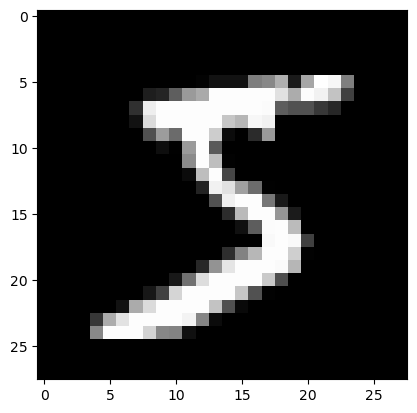

In [31]:
plot(train.data[0])

In [32]:
x = train.data.float() /255.
y = train.targets

x = x.view(x.size(0), -1)
print(x.shape, y.shape)

input_size = x.size(-1)
output_size = int(max(y)) +1

print('input_size: %d output_size: %d' %(input_size, output_size))

torch.Size([60000, 784]) torch.Size([60000])
input_size: 784 output_size: 10


In [34]:
ratio = [.5, .3, .2]

train_cnt = int(x.size(0) * ratio[0])  # 초기 학습 데이터 v1
retrain_cnt = int(x.size(0) * ratio[1])  # 재학습용 데이터 v2
valid_cnt = x.size(0) - train_cnt - retrain_cnt # 검증 데이터
test_cnt = len(test.data) # 테스트 데이터
cnts = [train_cnt, retrain_cnt, valid_cnt]

print("Train %d / Retrain %d  / Valid %d / Test %d samples." %(train_cnt, retrain_cnt, valid_cnt, test_cnt))

indices = torch.randperm(x.size(0))

x = torch.index_select(x, dim=0, index=indices)
y = torch.index_select(y, dim=0, index=indices)

x = list(x.split(cnts, dim = 0))
y = list(y.split(cnts, dim = 0))

x+=[(test.data.float() / 255.).view(test_cnt, -1)]
y+=[test.targets]

for x_i, y_i in zip(x, y):
    print(x_i.size(), y_i.size())


Train 30000 / Retrain 18000  / Valid 12000 / Test 10000 samples.
torch.Size([30000, 784]) torch.Size([30000])
torch.Size([18000, 784]) torch.Size([18000])
torch.Size([12000, 784]) torch.Size([12000])
torch.Size([10000, 784]) torch.Size([10000])


In [35]:
model = nn.Sequential(
    nn.Linear(input_size, 500),
    nn.LeakyReLU(),
    nn.Linear(500,400),
    nn.LeakyReLU(),
    nn.Linear(400,300),
    nn.LeakyReLU(),
    nn.Linear(300,200),
    nn.LeakyReLU(),
    nn.Linear(200,100),
    nn.LeakyReLU(),
    nn.Linear(100,50),
    nn.LeakyReLU(),
    nn.Linear(50, output_size),
    nn.LogSoftmax(dim=-1),
)
optimizer = optim.Adam(model.parameters(), lr=0.002)
crit = nn.NLLLoss()

In [36]:
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

model = model.to(device) # 모델을 메인메모리에서 gpu가 있는 그래픽카드로 이동

x = [x_i.to(device) for x_i in x] # 데이터들도 그래픽카드로 이동
y = [y_i.to(device) for y_i in y]

In [37]:
n_epochs = 1000         # 에폭 수 : 1000
batch_size = 256        # 배치 사이즈 : 256
print_interval = 10

lowest_loss = np.inf
best_model = None

early_stop = 25         # 50번의 에폭동안 오차값이 줄어들지 않으면 조기 종료하도록
lowest_epoch = np.inf

In [42]:
import time # elapsed_time 때문에

train_history, valid_history = [], []

start_time = time.time() # elapsed_time 때문에

for i in range(n_epochs):
    indices = torch.randperm(x[0].size(0)).to(device)
    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)

    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0
    y_hat = []

    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)
        loss = crit(y_hat_i, y_i.squeeze())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += float(loss)

    train_loss = train_loss / len(x_)

    with torch.no_grad(): # 검증데이터
        x_ = x[2].split(batch_size, dim=0)
        y_ = y[2].split(batch_size, dim=0)

        valid_loss = 0

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = crit(y_hat_i, y_i.squeeze())

            valid_loss += float(loss)
            y_hat += [y_hat_i]

    valid_loss = valid_loss / len(x_)

    train_history += [train_loss]
    valid_history += [valid_loss]

    elapsed_time = time.time() - start_time # elapsed_time 때문에

    if (i + 1) % print_interval == 0:
        print(
            'Epoch %d: train loss=%.4f  valid_loss=%.4e  lowest_loss=%.4e elapsed_time=%.2fsec' %
            (i + 1, train_loss, valid_loss, lowest_loss, elapsed_time)
        )

    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())

    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1: #가장 최솟값을 가지는 곳으로부터 조기종료 에폭수 100을 더한것보다 지금의 i가 더 크면 이건 조기종료를 하고 탈출해야한다
            print("There is no improvement during last %d epochs." % early_stop)
            break

print("The best validation loss from epoch %d: %.4e" %
      (lowest_epoch + 1, lowest_loss))

model.load_state_dict(best_model) # 최소손실 상태로 모델이 복귀한다

Epoch 10: train loss=0.0120  valid_loss=1.6480e-01  lowest_loss=1.2233e-01 elapsed_time=4.09sec
Epoch 20: train loss=0.0096  valid_loss=1.7039e-01  lowest_loss=1.2233e-01 elapsed_time=7.83sec
Epoch 30: train loss=0.0082  valid_loss=1.7508e-01  lowest_loss=1.2233e-01 elapsed_time=11.73sec
There is no improvement during last 25 epochs.
The best validation loss from epoch 11: 1.2233e-01


<All keys matched successfully>

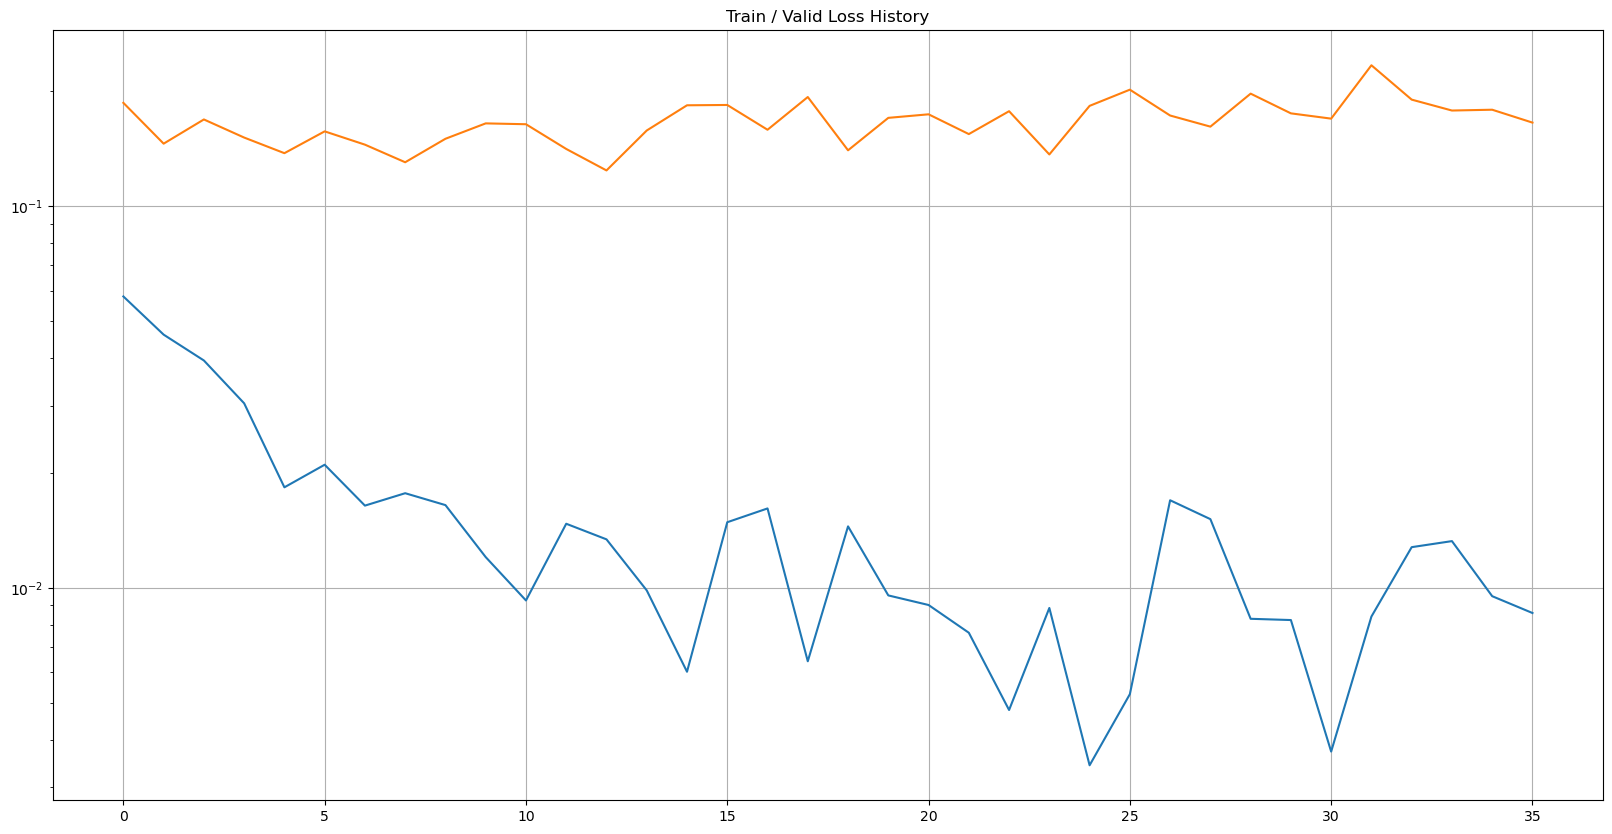

In [43]:
plot_from = 0

plt.figure(figsize=(20,10))
plt.grid(True)
plt.title('Train / Valid Loss History')
plt.plot(range(plot_from, len(train_history)), train_history[plot_from:], label='Train Loss')
plt.plot(range(plot_from, len(valid_history)), valid_history[plot_from:], label='Valid Loss')
plt.yscale('log')
plt.show()


In [44]:
test_loss = 0
y_hat=[]

with torch.no_grad(): # 테스트 데이터
        x_ = x[3].split(batch_size, dim=0)
        y_ = y[3].split(batch_size, dim=0)

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = crit(y_hat_i, y_i.squeeze())

            test_loss += loss
            y_hat += [y_hat_i]

test_loss = test_loss / len(x_)
y_hat = torch.cat(y_hat, dim=0)

print('Test Loss: %.4e'%test_loss)

Test Loss: 1.0234e-01


In [45]:
correct_cnt = (y[-1].squeeze() == torch.argmax(y_hat, dim=1)).sum()
total_cnt = float(y[-1].size(0))

print('Test Accuracy: %.4f' %(correct_cnt/total_cnt))

Test Accuracy: 0.9771


In [46]:
import pandas as pd
from sklearn.metrics import confusion_matrix

In [47]:
pd.DataFrame(confusion_matrix(y[-1], torch.argmax(y_hat, dim =1)),
             index = ['true_%d' % i for i in range(10)],
             columns = ['pred_%d' % i for i in range(10)])

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9
true_0,964,0,1,1,1,1,4,2,0,6
true_1,1,1124,4,1,0,0,2,2,1,0
true_2,3,1,1007,6,2,0,4,8,1,0
true_3,0,0,4,988,1,7,0,5,2,3
true_4,0,0,6,0,963,0,6,2,0,5
true_5,2,0,0,6,2,868,10,1,2,1
true_6,3,3,0,1,3,1,946,0,1,0
true_7,1,1,6,3,0,0,0,1011,2,4
true_8,2,0,5,5,2,5,14,2,936,3
true_9,2,3,0,7,20,6,0,6,1,964
